Tested threads with the following:
1. Ran "a.jl" at Raiden through "a.sh" with 1 MPI process. "a.jl" read:\
```re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)```\
Ran this 5 times (5 jobs). Results (in seconds):\
75.323871509\
75.993339872\
76.086517903\
76.29291494\
75.844033338
2. Ran "a.jl" at Raiden through "a.sh" with 10 MPI processes. "a.jl" read:\
```re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)```\
Result:\
72.8751464
3. Ran "a.jl" at Raiden through "a.sh" 10 times (10 jobs). "a.jl" read:\
```re_res, ghtime = @timed rangeexp_strip(15,16,1;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8)```\
Added up the @times for the jobs:\
12.319968545 +\
11.632396139 +\
11.844198664 +\
12.15444589 +\
11.300457402 +\
12.891287301 +\
12.988357535 +\
12.254190427 +\
12.024256677 +\
12.67187802 =\
122.0814356
4. Ran "a.jl" at Raiden through "a.sh" with 10 MPI processes. "a.jl" read:\
```re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=true)```
Ran this 3 times (3 jobs). Results (in seconds):\
81\
84\
84
5. Ran the same command as **1.** on my laptop for comparison:\
```re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)```\
Ran this 4 times. The laptop did not have anything else running and was restarted beforehand. Results (in seconds):\
167\
185\
194\
205
6. Ran the same command as **4.** on my laptop for comparison:\
```re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=true)```
Ran this 3 times. The laptop did not have anything else running and was restarted beforehand. Results (in seconds):\
133\
135.5\
132.9
7. Checked how long one process takes on my laptop, like in **3.**:\
```re_res, ghtime = @timed rangeexp_strip(15,16,1;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8)```\
Ran this 5 times. The laptop did not have anything else running and was restarted beforehand. Results (in seconds):\
28.5\
17.2\
16.9\
16.3\
17.3
7. Calculated average times for each trial and compared. Also, deserialised each result to check the contents\
---
Conclusions:
1) 10 threads (**1.**) take shorter than 10 jobs (**3.**), but if concurrent jobs are run (in **3.**), it's a ~x6 advantage. This can be combined, and the optimal solution is to run multiple threads in multiple jobs. The precise optimal number of threads should be determined for a specific machine. For now, I'm not going to implement combining the sets of multiprocessed/multithreaded results from different jobs. I'm also not going to implement combining the sets of multiprocessed and multithreaded results, albeit it could be an even better solution, at least in terms of tidiness of jobs (no job spam).
2) My laptop is 2~2.5 slower than Raiden with 10 processes or 10 threads
3) Multiproc runs 44% faster than multithread on my laptop
4) 
---

In [1]:
include("../resk.jl")

RESK successfully loaded.


### 6.

In [2]:
addprocs(9)
@everywhere include("../resk.jl")

RESK successfully loaded.
      From worker 6:	RESK successfully loaded.
      From worker 4:	RESK successfully loaded.
      From worker 7:	RESK successfully loaded.
      From worker 5:	RESK successfully loaded.
      From worker 9:	RESK successfully loaded.
      From worker 3:	RESK successfully loaded.
      From worker 10:	RESK successfully loaded.
      From worker 8:	RESK successfully loaded.
      From worker 2:	RESK successfully loaded.


In [5]:
re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=true)
ghtime

10


132.9058361

---
### 5.

In [3]:
re_res, ghtime = @timed rangeexp_strip(15,16,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)
ghtime

205.2964041

In [5]:
A = deserialize("data/test_threads.re")

OrderedDict{String, Any} with 5 entries:
  "stats" => OrderedDict{String, Any}("name"=>"2024-11-14_05-11-54", "max"=>(10…
  "gt1"   => Array{Array{Bool}}[[] [] … [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0…
  "gt2"   => Array{Array{Bool}}[[] [] … [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0…
  "fitn"  => Float32[0.997857 0.99855 … 0.999934 0.99933; 0.998688 0.998883 … 0…
  "pops"  => Float32[46.0 48.0 … 52.0 44.0; 55.0 28.0 … 47.0 41.0; … ; NaN NaN …

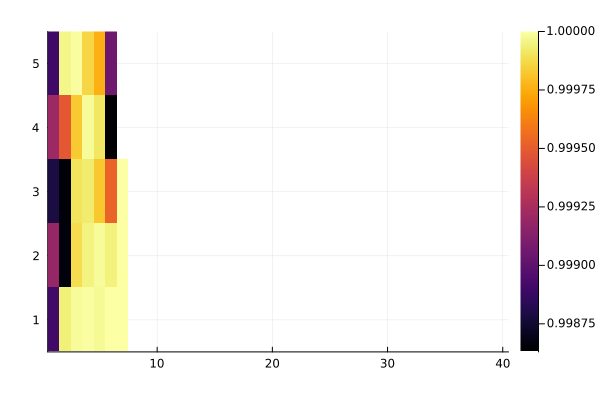

In [21]:
Plots.heatmap(A["fitn"][:,:,1,2]')

---
Another nice way to benchmark. TO DO!!! Build a benchmark for the final version:

In [ ]:
using BenchmarkTools
BenchmarkTools.DEFAULT_PARAMETERS.samples = 5
@btime test = rangeexp_strip(30,50,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=false)
@btime test2 = rangeexp_strip(30,50,10;data_to_generate="FPG",bottleneck=NaN,n_loci=110,mut_rate=0.8,multiproc=true)